In [1]:
import sys
import os

print("Python version:")
print(sys.version)

print("\nCurrent notebook folder:")
print(os.getcwd())

Python version:
3.14.4 (main, Jun 18 2026, 14:25:02) [GCC 15.2.0]

Current notebook folder:
/home/aau-training/Desktop/Practical_Training/Project4/Proj4_repo/notebooks


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /home/aau-
[nltk_data]     training/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
import os

for root, dirs, files in os.walk("/home"):
    if "Tweets.csv" in files:
        print(os.path.join(root, "Tweets.csv"))

/home/aau-training/snap/code/254/.local/share/Trash/files/data/Tweets.csv
/home/aau-training/Downloads/archive(1) (2)/Tweets.csv
/home/aau-training/Downloads/archive(1)/Tweets.csv
/home/aau-training/Desktop/Practical_Training/xxxx/xxxx/data/Tweets.csv
/home/aau-training/Desktop/Practical_Training/Project4/Proj4_repo/data/Tweets.csv


In [5]:
import os

os.chdir("/home/aau-training/Desktop/Practical_Training/Project4/Proj4_repo")

print(os.getcwd())

/home/aau-training/Desktop/Practical_Training/Project4/Proj4_repo


In [6]:
os.listdir()

['.gitignore',
 '.git',
 'README.md',
 'sentiment.db',
 'venv',
 'data',
 'app',
 'notebooks',
 'requirements.txt',
 'LICENSE',
 'embedding_model.pkl',
 'sentiment_model.pkl']

In [7]:
os.listdir("data")

['Tweets.csv', 'database.sqlite']

In [8]:
import pandas as pd

df = pd.read_csv("data/Tweets.csv")

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [9]:
df.shape

(14640, 15)

In [10]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str')

In [11]:
X = df["text"]
y = df["airline_sentiment"]

In [12]:
df.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [13]:
df["airline_sentiment"].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

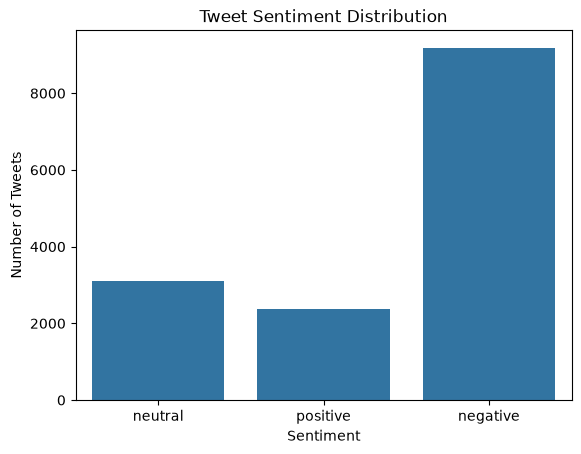

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    x="airline_sentiment",
    data=df
)

plt.title("Tweet Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

In [15]:
X = df["text"]
y = df["airline_sentiment"]

print(X.head())
print(y.head())

0                  @VirginAmerica What @dhepburn said.
1    @VirginAmerica plus you've added commercials t...
2    @VirginAmerica I didn't today... Must mean I n...
3    @VirginAmerica it's really aggressive to blast...
4    @VirginAmerica and it's a really big bad thing...
Name: text, dtype: str
0     neutral
1    positive
2     neutral
3    negative
4    negative
Name: airline_sentiment, dtype: str


In [16]:
print("Missing tweets:", X.isnull().sum())
print("Missing labels:", y.isnull().sum())

Missing tweets: 0
Missing labels: 0


In [17]:
import re
import nltk

from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))


def clean_text(text):

    # lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    # remove mentions (@user)
    text = re.sub(
        r"@\w+",
        "",
        text
    )

    # remove hashtags symbol
    text = re.sub(
        r"#",
        "",
        text
    )

    # remove punctuation and numbers
    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )

    # split words
    words = text.split()

    # remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

[nltk_data] Downloading package stopwords to /home/aau-
[nltk_data]     training/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
sample = X.iloc[0]

print("Original:")
print(sample)

print("\nCleaned:")
print(clean_text(sample))

Original:
@VirginAmerica What @dhepburn said.

Cleaned:
said


In [19]:
df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing


In [20]:
X = df["clean_text"]
y = df["airline_sentiment"]

print(X.head())
print(y.head())

0                                                 said
1        plus youve added commercials experience tacky
2         didnt today must mean need take another trip
3    really aggressive blast obnoxious entertainmen...
4                                 really big bad thing
Name: clean_text, dtype: str
0     neutral
1    positive
2     neutral
3    negative
4    negative
Name: airline_sentiment, dtype: str


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 11712
Testing samples: 2928


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)


print("Training feature shape:")
print(X_train_tfidf.shape)

print("\nTesting feature shape:")
print(X_test_tfidf.shape)

Training feature shape:
(11712, 5000)

Testing feature shape:
(2928, 5000)


In [23]:
print(tfidf.get_feature_names_out()[:20])

['aa' 'aaba' 'aadv' 'aadvantage' 'aano' 'aas' 'ab' 'abandon' 'abandoned'
 'abandonment' 'abassinet' 'abbreve' 'abc' 'abcletjetbluestreamfeed'
 'abcnews' 'abcs' 'abducted' 'abi' 'abidfw' 'abilities']


In [24]:
X_train_tfidf.shape

(11712, 5000)

In [25]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

print("Naive Bayes training complete")

Naive Bayes training complete


In [26]:
y_pred_nb = nb_model.predict(
    X_test_tfidf
)

print(y_pred_nb[:10])

['negative' 'negative' 'negative' 'negative' 'negative' 'negative'
 'negative' 'negative' 'negative' 'negative']


In [27]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression training complete")


Logistic Regression training complete


In [28]:
y_pred_lr = lr_model.predict(
    X_test_tfidf
)

print(y_pred_lr[:10])

['negative' 'negative' 'negative' 'negative' 'negative' 'negative'
 'negative' 'negative' 'negative' 'neutral']


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [30]:
def evaluate_model(name, y_test, y_pred):

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy:",
          accuracy_score(y_test, y_pred))

    print("Precision:",
          precision_score(
              y_test,
              y_pred,
              average="weighted"
          ))

    print("Recall:",
          recall_score(
              y_test,
              y_pred,
              average="weighted"
          ))

    print("F1 Score:",
          f1_score(
              y_test,
              y_pred,
              average="weighted"
          ))

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred
        )
    )

In [31]:
evaluate_model(
    "Naive Bayes",
    y_test,
    y_pred_nb
)

Naive Bayes
Accuracy: 0.7223360655737705
Precision: 0.7417168221155362
Recall: 0.7223360655737705
F1 Score: 0.6710291403234451

Classification Report:
              precision    recall  f1-score   support

    negative       0.71      0.99      0.83      1835
     neutral       0.73      0.24      0.36       620
    positive       0.87      0.33      0.48       473

    accuracy                           0.72      2928
   macro avg       0.77      0.52      0.55      2928
weighted avg       0.74      0.72      0.67      2928



In [32]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr
)

Logistic Regression
Accuracy: 0.7814207650273224
Precision: 0.7742628027367888
Recall: 0.7814207650273224
F1 Score: 0.7670934399001229

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.94      0.87      1835
     neutral       0.66      0.48      0.56       620
    positive       0.82      0.55      0.66       473

    accuracy                           0.78      2928
   macro avg       0.76      0.66      0.69      2928
weighted avg       0.77      0.78      0.77      2928



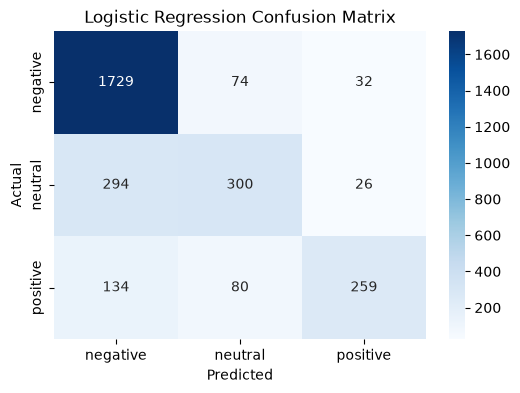

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [34]:
evaluate_model(
    "Naive Bayes",
    y_test,
    y_pred_nb
)

Naive Bayes
Accuracy: 0.7223360655737705
Precision: 0.7417168221155362
Recall: 0.7223360655737705
F1 Score: 0.6710291403234451

Classification Report:
              precision    recall  f1-score   support

    negative       0.71      0.99      0.83      1835
     neutral       0.73      0.24      0.36       620
    positive       0.87      0.33      0.48       473

    accuracy                           0.72      2928
   macro avg       0.77      0.52      0.55      2928
weighted avg       0.74      0.72      0.67      2928



In [35]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr
)

Logistic Regression
Accuracy: 0.7814207650273224
Precision: 0.7742628027367888
Recall: 0.7814207650273224
F1 Score: 0.7670934399001229

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.94      0.87      1835
     neutral       0.66      0.48      0.56       620
    positive       0.82      0.55      0.66       473

    accuracy                           0.78      2928
   macro avg       0.76      0.66      0.69      2928
weighted avg       0.77      0.78      0.77      2928



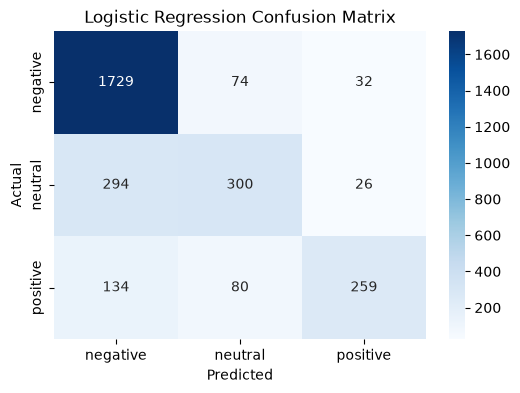

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [37]:
from sentence_transformers import SentenceTransformer

In [38]:
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Embedding model loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded


In [39]:
X_train_emb = embedding_model.encode(
    X_train.tolist(),
    show_progress_bar=True
)

X_test_emb = embedding_model.encode(
    X_test.tolist(),
    show_progress_bar=True
)

print("Training embeddings shape:")
print(X_train_emb.shape)

print("\nTesting embeddings shape:")
print(X_test_emb.shape)

Batches:   0%|          | 0/366 [00:00<?, ?it/s]

Batches:   0%|          | 0/92 [00:00<?, ?it/s]

Training embeddings shape:
(11712, 384)

Testing embeddings shape:
(2928, 384)


In [40]:
lr_emb_model = LogisticRegression(
    max_iter=1000
)

lr_emb_model.fit(
    X_train_emb,
    y_train
)

print("Embedding Logistic Regression trained")

Embedding Logistic Regression trained


In [41]:
y_pred_emb = lr_emb_model.predict(
    X_test_emb
)

print(y_pred_emb[:10])

['neutral' 'negative' 'negative' 'negative' 'negative' 'negative'
 'neutral' 'positive' 'negative' 'negative']


In [42]:
evaluate_model(
    "Embedding Logistic Regression",
    y_test,
    y_pred_emb
)

Embedding Logistic Regression
Accuracy: 0.7855191256830601
Precision: 0.7797684773779355
Recall: 0.7855191256830601
F1 Score: 0.7796283794159765

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.91      0.87      1835
     neutral       0.63      0.58      0.60       620
    positive       0.77      0.59      0.67       473

    accuracy                           0.79      2928
   macro avg       0.74      0.69      0.71      2928
weighted avg       0.78      0.79      0.78      2928



In [43]:
comparison = pd.DataFrame({
    "Feature": [
        "TF-IDF",
        "Embeddings"
    ],
    "Accuracy": [
        0.7814,
        0.7855
    ],
    "F1-score": [
        0.7671,
        0.7796
    ]
})

comparison

,Feature,Accuracy,F1-score
0,TF-IDF,0.7814,0.7671
1,Embeddings,0.7855,0.7796


In [44]:
LogisticRegression(max_iter=1000)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression


params = {
    "C": [0.01, 0.1, 1, 10, 100]
}


lr = LogisticRegression(
    max_iter=1000
)


grid = GridSearchCV(
    lr,
    params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)


grid.fit(
    X_train_emb,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with

In [46]:
grid.best_params_

{'C': 1}

In [47]:
grid.best_score_

np.float64(0.7786046632153756)

In [48]:
best_model = grid.best_estimator_

In [49]:
y_pred_tuned = best_model.predict(
    X_test_emb
 )

In [50]:
evaluate_model(
    "Tuned Embedding Logistic Regression",
    y_test,
    y_pred_tuned
)

Tuned Embedding Logistic Regression
Accuracy: 0.7855191256830601
Precision: 0.7797684773779355
Recall: 0.7855191256830601
F1 Score: 0.7796283794159765

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.91      0.87      1835
     neutral       0.63      0.58      0.60       620
    positive       0.77      0.59      0.67       473

    accuracy                           0.79      2928
   macro avg       0.74      0.69      0.71      2928
weighted avg       0.78      0.79      0.78      2928



In [51]:
grid.best_params_

{'C': 1}

In [52]:
best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(
    X_test_emb
)

evaluate_model(
    "Tuned Embedding Logistic Regression",
    y_test,
    y_pred_tuned
)

Tuned Embedding Logistic Regression
Accuracy: 0.7855191256830601
Precision: 0.7797684773779355
Recall: 0.7855191256830601
F1 Score: 0.7796283794159765

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.91      0.87      1835
     neutral       0.63      0.58      0.60       620
    positive       0.77      0.59      0.67       473

    accuracy                           0.79      2928
   macro avg       0.74      0.69      0.71      2928
weighted avg       0.78      0.79      0.78      2928



In [53]:
comparison = pd.DataFrame({

    "Model": [
        "TF-IDF + Logistic Regression",
        "Embeddings + Logistic Regression",
        "Tuned Embeddings + Logistic Regression"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_emb),
        accuracy_score(y_test, y_pred_tuned)
    ],

    "F1 Score": [
        f1_score(
            y_test,
            y_pred_lr,
            average="weighted"
        ),

        f1_score(
            y_test,
            y_pred_emb,
            average="weighted"
        ),

        f1_score(
            y_test,
            y_pred_tuned,
            average="weighted"
        )
    ]
})


comparison

,Model,Accuracy,F1 Score
0,TF-IDF + Logistic Regression,0.781421,0.767093
1,Embeddings + Logistic Regression,0.785519,0.779628
2,Tuned Embeddings + Logistic Regression,0.785519,0.779628


In [54]:
import joblib

joblib.dump(
    best_model,
    "sentiment_model.pkl"
)

print("Model saved")

Model saved


In [55]:
joblib.dump(
    embedding_model,
    "embedding_model.pkl"
)

print("Embedding model saved")

Embedding model saved


In [56]:
del best_model
del embedding_model

In [57]:
loaded_model = joblib.load(
    "sentiment_model.pkl"
)

loaded_embedding = joblib.load(
    "embedding_model.pkl"
)

print("Models loaded successfully")

Models loaded successfully


In [58]:
def predict_sentiment(text):

    cleaned = clean_text(text)

    embedding = loaded_embedding.encode(
        [cleaned]
    )

    prediction = loaded_model.predict(
        embedding
    )

    return prediction[0]

In [59]:
predict_sentiment(
    "I love this airline, the service was amazing"
)

'positive'

In [60]:
predict_sentiment(
    "The flight was horrible and the staff were rude"
)

'negative'

In [61]:
predict_sentiment(
    "The flight departed on time"
)

'negative'

In [62]:
comparison

,Model,Accuracy,F1 Score
0,TF-IDF + Logistic Regression,0.781421,0.767093
1,Embeddings + Logistic Regression,0.785519,0.779628
2,Tuned Embeddings + Logistic Regression,0.785519,0.779628


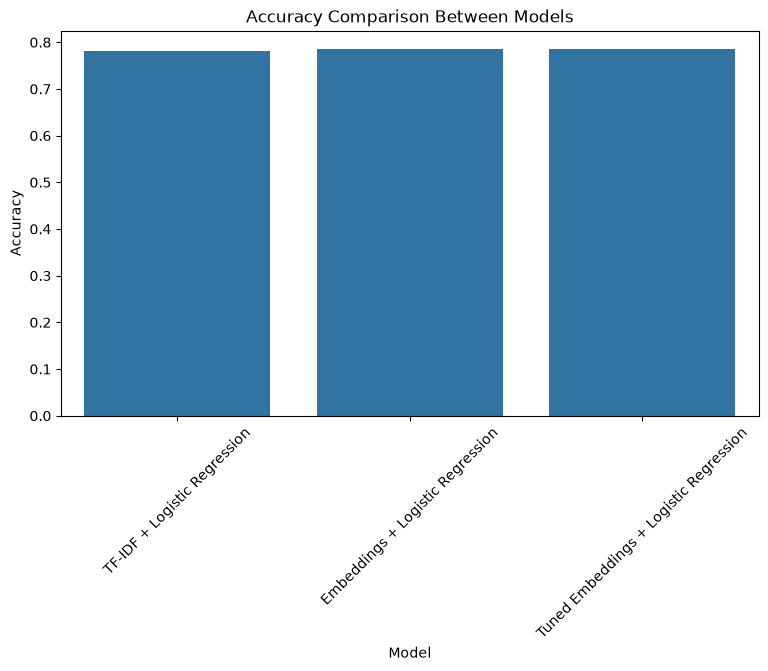

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=45)
plt.title("Accuracy Comparison Between Models")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

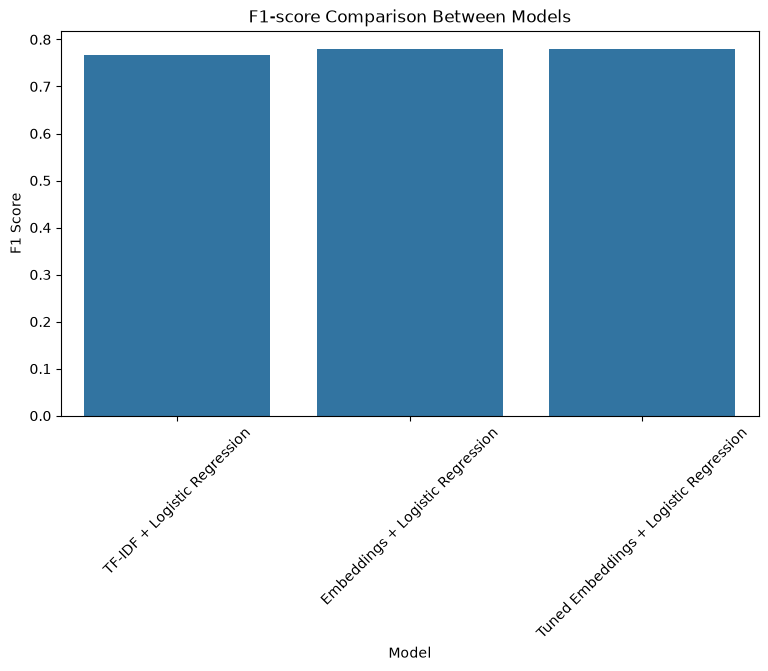

In [64]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="F1 Score"
)

plt.xticks(rotation=45)
plt.title("F1-score Comparison Between Models")

plt.show()

In [65]:
!pip install sqlalchemy alembic